This notebook plots the solutions. You can actually plot the progress while the solver is running to see if it makes sense.

Various imports:

In [1]:
%load_ext autoreload
%autoreload 2
# add path to code
import sys
sys.path.insert(0, '../source')
import numpy as np
from matplotlib.tri import Triangulation
from matplotlib import colors
import matplotlib.pyplot as plt
import matplotlib as mpl
import topotoolbox as tt3
from params import rho_w,g
from scipy.stats import linregress
from load_lakes import lake_inventory
import json

In [2]:
#choose which results to load
results_name = '../results/Cook_E2_370kpa_nostorage'

In [3]:
t = np.load(results_name+'/t.npy')
nodes_x = np.load(results_name+'/nodes_x.npy')/1e3
nodes_y = np.load(results_name+'/nodes_y.npy')/1e3
dofmap = np.load(results_name+'/dofmap.npy')
triang = Triangulation(nodes_x,nodes_y,dofmap)

# load results and reorder dof's to the serial ordering
N = np.load(results_name+'/N.npy')
b = np.load(results_name+'/b.npy')
qx = np.load(results_name+'/qx.npy')
qy = np.load(results_name+'/qy.npy')
lake_bdry = np.load(results_name+'/lake_bdry.npy')
outflow_dofs = np.load(results_name+'/outflow_dofs.npy')

boundary_coords = np.load(results_name+'/boundary_coords.npy')/1e3
outflow_coords = np.load(results_name+'/outflow_coords.npy')/1e3

# get water flow speed
q_m = np.sqrt(qx**2+qy**2)

with open(results_name+"/model_config.json", "r") as f:
    model_config = json.load(f)

lake_name = model_config['lake_name']
outflow_on = model_config['outflow_on']
storage_on = model_config['storage_on']
N_bdry = model_config['lake_name']
x_min = model_config['x_min']/1e3
x_max = model_config['x_max']/1e3
y_min = model_config['y_min']/1e3
y_max = model_config['y_max']/1e3

outline = lake_inventory.loc[lake_inventory['name']==lake_name]

In [4]:
# get mean of N over the lake and max of q not over the lake
N_mean = np.zeros(t.size)
b_mean = np.zeros(t.size)
q_max = np.zeros(t.size)

j_max=0

for j in range(t.size):
    if np.max(q_m[j,:]>1e-10):
        N_j = N[j,:]
        b_j = b[j,:]
        q_j = q_m[j,:]
        
        if np.max(lake_bdry)>1e-10:
            # if storage take mean of pressure over lake area
            # and max of disharge 
            N_mean[j] = np.mean(N_j[lake_bdry>1e-2])
            b_mean[j] = np.mean(b_j[lake_bdry>1e-2])
            q_max[j] = np.max(q_j[lake_bdry<1e-2])

        else:
            # if no lake, just take mean over whole domain
            N_mean[j] = np.mean(N_j)
            b_mean[j] = np.mean(b_j)
            q_max[j] = np.max(q_j)
            
        j_max+=1 
j_max -= 1

# storage in the lake, assuming water density 1000 kg/m^3
b_L = -(N_mean-N_mean[0])/(rho_w*g)

In [5]:
# get dem for topotoolbox plotting
dem = tt3.read_tif('potenetial_dem_plotting.tif')
fd = tt3.FlowObject(dem)
s   = tt3.StreamObject(fd,threshold=2000,units='pixels')

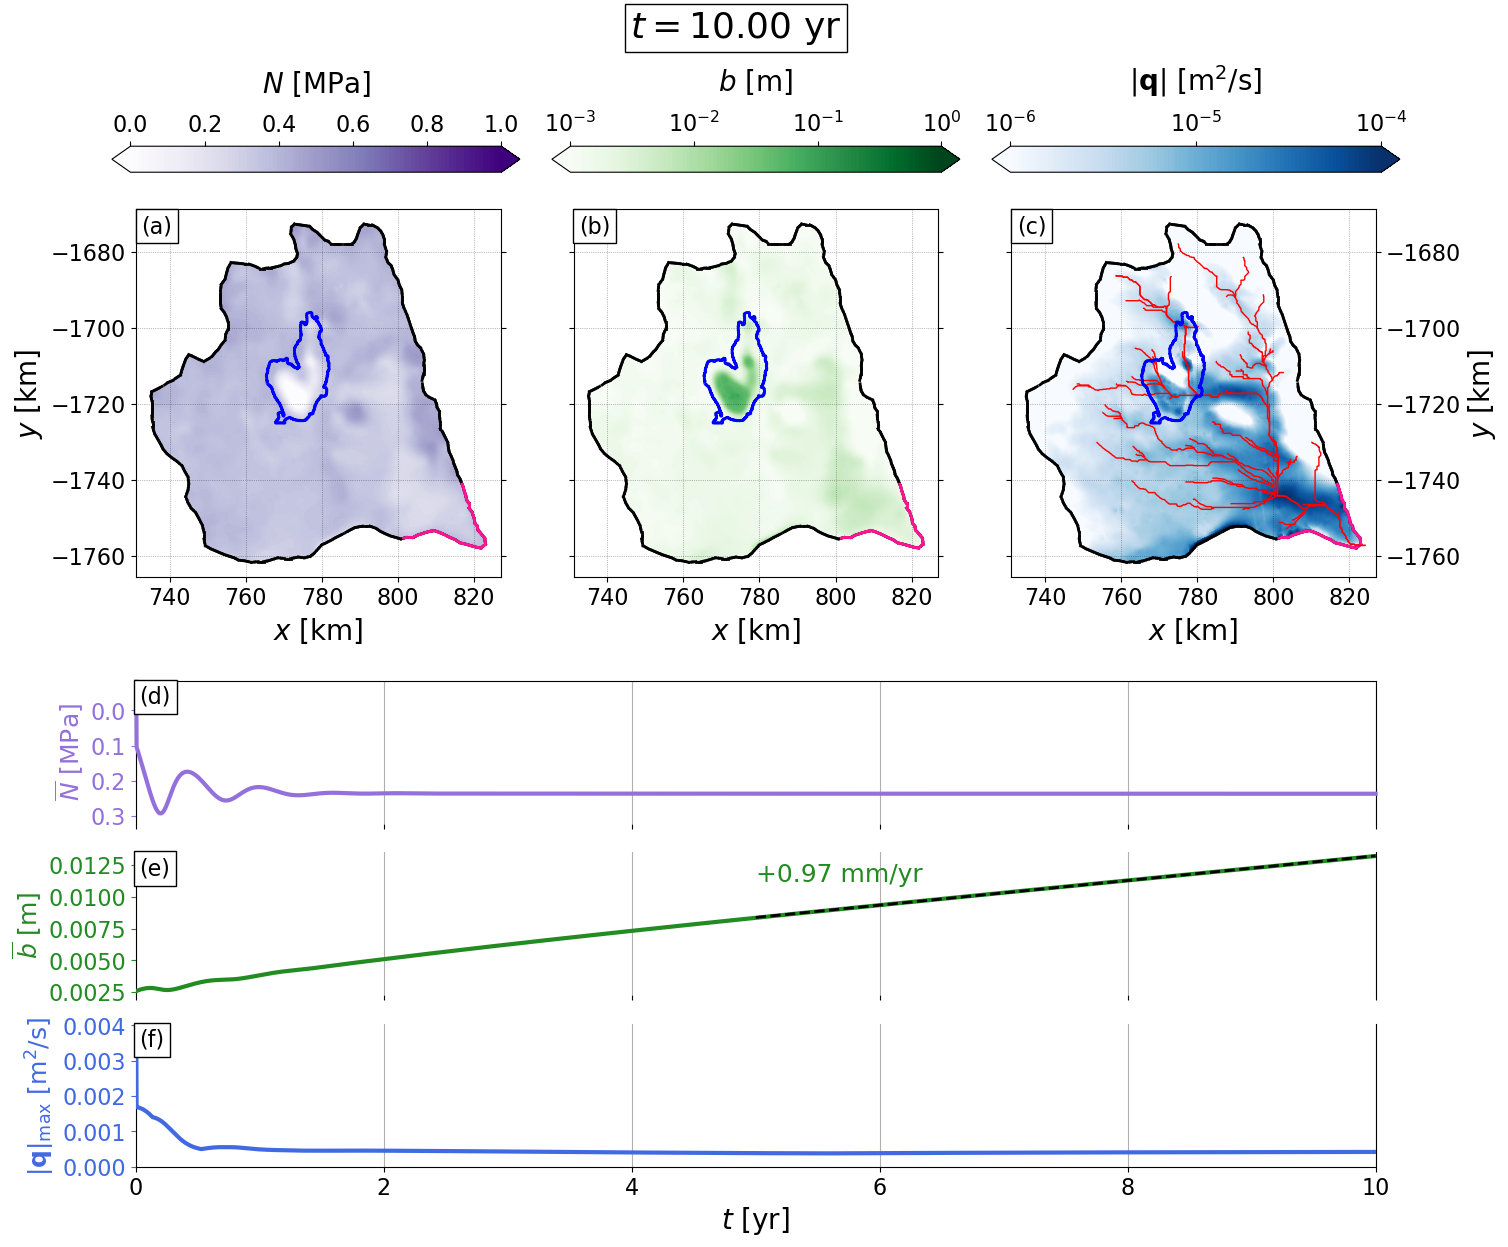

In [6]:
# choose to plot a single timestep OR a sequence to make a movie
ind = [j_max]               # plot a single time step
# ind = np.arange(1,j_max,1) # plot every time step for saving a movie

# make clean movie directory
# !rm -rf {results_name}/movie
# !mkdir {results_name}/movie

j=0

if len(ind)>1:
# use agg backend for saving pngs
    mpl.use('agg')
else:
    %matplotlib inline

qlim2 = -4 #np.floor(np.log10(np.max(q_m)))
qlim1 = -6 #np.ceil(np.log10(np.mean(q_m[:,1:j_max])))

t_scale = 1.0 # 1 for years, 365 for days
if int(t_scale)==365:
    t_str = 'd' 
elif int(t_scale)==1:
    t_str = 'yr'
slope, intercept, r_value, p_value, std_err = linregress(t[int(0.5*(j_max)):j_max]*(t_scale/3.154e7), b_L[int(0.5*(j_max)):j_max])

slope2, intercept2, r_value2, p_value2, std_err2 = linregress(t[int(0.5*(j_max)):j_max]*(t_scale/3.154e7), b_mean[int(0.5*(j_max)):j_max])
res_lim = 10

for i in ind:
    print('saved image '+str(j+1)+' out of '+str(len(ind))+' \r',end='')
    
    fig = plt.figure(figsize=(16,13))
    
    plt.suptitle(r'$t=$'+'{:.2f}'.format(t_scale*t[i]/3.154e7)+f' {t_str}',y=1.0,fontsize=26,bbox=dict(facecolor='w', alpha=1))

    ax1 = plt.subplot(231)
    plt.annotate(r'(a)',xy=(0.015,0.935),xycoords='axes fraction',fontsize=16,bbox=dict(facecolor='w', edgecolor='k'))
    plt.grid(alpha=0.5,linestyle=':',color='k',linewidth=0.5)
    N_i = N[i]
    for coords in boundary_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            plt.plot(coords[:, 0], coords[:, 1], color='black',linewidth=2)
    for coords in outflow_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            plt.plot(coords[:, 0], coords[:, 1], color='deeppink',linewidth=2)
    p1 = plt.tricontourf(triang,N_i/1e6,levels=np.linspace(0,1,100),cmap='Purples',extend='both')
    if lake_name != 'none':
        outline.plot(edgecolor='b',linestyle='-',facecolor='none',ax=plt.gca(),linewidth=2,zorder=100,alpha=1)  
    else:
        plt.tricontour(triang,lake_bdry,levels=[0.001],colors='k',linestyles='-',linewidths=2)
    plt.xlim(x_min,x_max)
    plt.ylim(y_min,y_max)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel(r'$x$ [km]',fontsize=20)
    plt.ylabel(r'$y$ [km]',fontsize=20)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.gca().tick_params(axis='y', which='both', labelright=False, right=True)
    cbar_ax = fig.add_axes([0.11, 0.875, 0.255, 0.02])
    cbar = plt.colorbar(p1,orientation='horizontal',ticks=np.linspace(0,1,6),cax=cbar_ax)
    cbar.set_label(r'$N$ [MPa]',fontsize=20,labelpad=15)
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')

    ax2 = plt.subplot(232)
    plt.annotate(r'(b)',xy=(0.015,0.935),xycoords='axes fraction',fontsize=16,bbox=dict(facecolor='w', edgecolor='k'))
    plt.grid(alpha=0.5,linestyle=':',color='k',linewidth=0.5)
    b_i = b[i]
    for coords in boundary_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            plt.plot(coords[:, 0], coords[:, 1], color='black',linewidth=2)
    for coords in outflow_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            plt.plot(coords[:, 0], coords[:, 1], color='deeppink',linewidth=2)
    p1 = plt.tricontourf(triang,b_i,cmap='Greens',extend='both',norm=colors.LogNorm(),levels=np.logspace(-3,0,100))
    if lake_name != 'none':
        outline.plot(edgecolor='b',linestyle='-',facecolor='none',ax=plt.gca(),linewidth=2,zorder=100,alpha=1)  
    else:
        plt.tricontour(triang,lake_bdry,levels=[0.001],colors='k',linestyles='-',linewidths=2)
    plt.xlim(x_min,x_max)
    plt.ylim(y_min,y_max)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel(r'$x$ [km]',fontsize=20)
    plt.gca().tick_params(axis='y', which='both', labelright=False, right=True)
    plt.xticks(fontsize=16)
    plt.gca().yaxis.set_ticklabels([])
    cbar_ax = fig.add_axes([0.385, 0.875, 0.255, 0.02])
    cbar = plt.colorbar(p1,orientation='horizontal',ticks=np.logspace(-3,0,4),cax=cbar_ax)
    cbar.set_label(r'$b$ [m]',fontsize=20,labelpad=15)
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')

    ax3 = plt.subplot(233)
    plt.annotate(r'(c)',xy=(0.015,0.935),xycoords='axes fraction',fontsize=16,bbox=dict(facecolor='w', edgecolor='k'))
    plt.grid(alpha=0.5,linestyle=':',color='k',linewidth=0.5)
    q_i = q_m[i]
    for coords in boundary_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            plt.plot(coords[:, 0], coords[:, 1], color='black',linewidth=2)
    for coords in outflow_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            plt.plot(coords[:, 0], coords[:, 1], color='deeppink',linewidth=2)
    p2 = plt.tricontourf(triang,q_i,cmap='Blues',extend='both',norm=colors.LogNorm(),levels=np.logspace(qlim1,qlim2,100))
    if lake_name != 'none':
        outline.plot(edgecolor='b',linestyle='-',facecolor='none',ax=plt.gca(),linewidth=2,zorder=100,alpha=1)  
    else:
        plt.tricontour(triang,lake_bdry,levels=[0.001],colors='k',linestyles='-',linewidths=2)
    plt.xlim(x_min,x_max)
    plt.ylim(y_min,y_max)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel(r'$x$ [km]',fontsize=20)
    plt.gca().yaxis.set_label_position("right")
    plt.gca().yaxis.tick_right()
    plt.ylabel(r'$y$ [km]',fontsize=20)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.gca().tick_params(axis='y', which='both', labelleft=False, left=True)
    
    #------- stream plot ------------
    xtix = ax3.get_xticks()
    ytix = ax3.get_yticks()
    xlim = ax3.get_xlim()
    ylim = ax3.get_ylim()

    dem.plot(ax3,cmap="terrain",alpha=0) 
    (s.klargestconncomps(1)).plot(ax=ax3,color='r',linewidth=1)
    (s.klargestconncomps(1).trunk()).plot(ax=ax3,color='r',linewidth=1)
    ax3.invert_yaxis()
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    ax3.tick_params(axis='y', which='both', labelleft=False, left=True)
    ax3.set_xticks(xtix)
    ax3.set_yticks(ytix)
    ax3.set_xlim(xlim)
    ax3.set_ylim(ylim)
    #-------------------------------
    cbar_ax = fig.add_axes([0.66, 0.875, 0.255, 0.02])
    cbar = plt.colorbar(p2,cax=cbar_ax,orientation='horizontal',ticks=np.logspace(qlim1,qlim2,1+int(np.abs(qlim2-qlim1))))#,format='%.0e')
    cbar.set_label(r'$|\mathbf{q}|$ [m$^2/$s]',fontsize=20,labelpad=15)
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')
    
    plt.subplot(614)
    plt.annotate(r'(d)',xy=(0.003,0.84),xycoords='axes fraction',fontsize=16,bbox=dict(facecolor='w', edgecolor='k'),zorder=200)

    if storage_on == True:
        t_apprx = t[int(0.5*(j_max)):j_max]*t_scale/3.154e7
        apprx = slope*t[int(0.5*(j_max)):j_max]*(t_scale/3.154e7)+intercept
        line1, = plt.plot(t[1:i]*t_scale/3.154e7,b_L[1:i],color='mediumpurple',linewidth=3,zorder=10) 
        if i>int(0.5*(j_max)):
            plt.plot(t_apprx[0:i-int(0.5*(j_max))],apprx[0:i-int(0.5*(j_max))],linewidth=2,color='k',linestyle='--',zorder=100)
        if i>int(0.75*(j_max)):
            plt.annotate(f'{slope*1e2:+.2f} cm/{t_str}',xy=(t_apprx[0],apprx[0]+1.5*np.std(apprx)),fontsize=18,color='mediumpurple')
        plt.xticks(fontsize=16)
        plt.yticks(fontsize=16)
        plt.gca().tick_params(axis='y', colors="mediumpurple")
        plt.ylabel(r'$\dfrac{\overline{N}_0-\overline{N}}{\rho_\mathrm{w}g}$ [m] ',fontsize=18,color='mediumpurple',zorder=99)
        plt.xlim(0,t[j_max]*t_scale/3.154e7)
        plt.ylim(b_L[0:j_max].min(),b_L[0:j_max].max())
        plt.gca().spines['bottom'].set_visible(False)
        plt.grid(axis='x')
        plt.gca().xaxis.set_ticklabels([])
        line1.set_clip_on(False)
    else:
        line0, = plt.plot(t[1:i]*t_scale/3.154e7,(N_mean[1:i])/1e6,color='mediumpurple',linestyle='-',linewidth=3,zorder=100)
        plt.xticks(fontsize=16)
        plt.yticks(fontsize=16)
        plt.gca().tick_params(axis='y', colors="mediumpurple")
        plt.ylabel(r'$\overline{N}$ [MPa]',fontsize=18,color='mediumpurple')
        plt.ylim((N_mean[0:j_max].max()+0.25*np.std(N_mean[0:j_max]))/1e6,(N_mean[0:j_max].min()-0.25*np.std(N_mean[0:j_max]))/1e6)
        plt.xlim(0,t[j_max]*t_scale/3.154e7)
        plt.gca().xaxis.set_ticklabels([])
        plt.gca().spines['bottom'].set_visible(False)
        plt.grid(axis='x')
        line0.set_clip_on(False)
    
    plt.subplot(616)
    plt.annotate(r'(f)',xy=(0.003,0.84),xycoords='axes fraction',fontsize=16,bbox=dict(facecolor='w', edgecolor='k'),zorder=200)
    plt.plot(t[1:i]*t_scale/3.154e7,q_max[1:i],color='royalblue',linewidth=3,zorder=10) 
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.gca().tick_params(axis='y', colors="royalblue")
    plt.ylabel(r'$|\mathbf{q}|_\mathrm{max}$ [m$^2$/s] ',fontsize=18,color='royalblue')
    plt.xlim(0,t[j_max]*t_scale/3.154e7)
    plt.ylim(0,q_max.max()+0.1*np.std(q_max))
    plt.gca().spines['top'].set_visible(False)
    plt.grid(axis='x')
    plt.xlabel(r'$t$ [yr]',fontsize=20)

    ax4 = plt.subplot(615)
    plt.annotate(r'(e)',xy=(0.003,0.84),xycoords='axes fraction',fontsize=16,bbox=dict(facecolor='w', edgecolor='k'),zorder=200)
    plt.plot(t[1:i]*t_scale/3.154e7,b_mean[1:i],color='forestgreen',linewidth=3,zorder=10) 

    t_apprx2 = t[int(0.5*(j_max)):j_max]*t_scale/3.154e7
    apprx2 = slope2*t[int(0.5*(j_max)):j_max]*(t_scale/3.154e7)+intercept2
    if i>int(0.5*(j_max)):
        plt.plot(t_apprx2[0:i-int(0.5*(j_max))],apprx2[0:i-int(0.5*(j_max))],linewidth=2,color='k',linestyle='--',zorder=100)
    if i>int(0.75*(j_max)):
        plt.annotate(f'{slope2*1e3:+.2f} mm/{t_str}',xy=(t_apprx2[0],apprx2[0]+2*np.std(apprx2)),fontsize=18,color='forestgreen')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.gca().tick_params(axis='y', colors="forestgreen")
    plt.ylabel(r'$\overline{b}$ [m] ',fontsize=18,color='forestgreen')
    plt.xlim(0,t[j_max]*t_scale/3.154e7)
    plt.ylim(b_mean[0:j_max].min()-0.1*np.std(b_mean),b_mean.max()+0.1*np.std(b_mean))
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.grid(axis='x')
    plt.gca().xaxis.set_ticklabels([])
    

    if len(ind)>1:
        plt.savefig('{}/movie/movie_'.format(results_name)+str(j),bbox_inches='tight')
    if len(ind)==1:
        plt.savefig('fig',bbox_inches='tight')
        plt.show()
    plt.close()
    j+=1

In [7]:
# check value of far-field effective pressure if simulation runs
# for longer than a year... is similar to outlet b.c. value? 
outflow_inds = np.ones(N_i.size)
outflow_inds[outflow_dofs]=0
if j_max > 365:
    N_far = np.zeros(365)

    for j in range(365):
        N_j = N[j+j_max-365,:]
        N_far[j] = np.mean(N_j[(lake_bdry<1e-2)&(outflow_inds>1e-8)])
    print(f'N_far = {N_far.mean()/1e6:.2f} MPa')

N_far = 0.36 MPa
